<a href="https://colab.research.google.com/github/lilian662/SIMULACION-I/blob/main/Flecha%20y%20cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problema: Ensamblaje flecha-cojinete

EDITH LILIAN CASTILLO OJEDA
19/05/2026



Se tiene que el diámetro del cojinete y el diámetro de la flecha siguen distribuciones normales:

$$
X_1 \sim N(1.5,0.0016)
$$

$$
X_2 \sim N(1.48,0.0009)
$$

donde:

- $X_1$: diámetro del cojinete  
- $X_2$: diámetro de la flecha  

La interferencia ocurre cuando:

$$
X_2>X_1
$$

## Solución analítica

Definimos:

$$
Y=X_2-X_1
$$

Como son normales independientes:

$$
Y\sim N(\mu_Y,\sigma_Y^2)
$$

La media es:

$$
\mu_Y=1.48-1.5=-0.02
$$

La varianza:

$$
\sigma_Y^2=0.0009+0.0016=0.0025
$$

Entonces:

$$
\sigma_Y=\sqrt{0.0025}=0.05
$$

Por lo tanto:

$$
Y\sim N(-0.02,0.0025)
$$

La probabilidad buscada es:

$$
P(X_2>X_1)
$$

equivalentemente:

$$
P(Y>0)
$$

Estandarizando:

$$
Z=\frac{0-(-0.02)}{0.05}
$$

$$
Z=0.4
$$

Entonces:

$$
P(Y>0)=P(Z>0.4)
$$

Usando la tabla normal:

$$
\Phi(0.4)=0.6554
$$

Finalmente:

$$
P(\text{interferencia})=1-0.6554
$$

$$
P(\text{interferencia})=0.3446
$$



## Simulación Monte Carlo

Se generarán observaciones para:

$$
X_1\sim N(1.5,0.0016)
$$

y

$$
X_2\sim N(1.48,0.0009)
$$

Posteriormente se contará el número de veces que ocurra:

$$
X_2>X_1
$$

La probabilidad estimada será comparada con el resultado analítico.

Número de simulaciones = 8676
Probabilidad analítica = 0.3446
Probabilidad simulada = 0.3359843245735362
Error = 0.008615675426463798


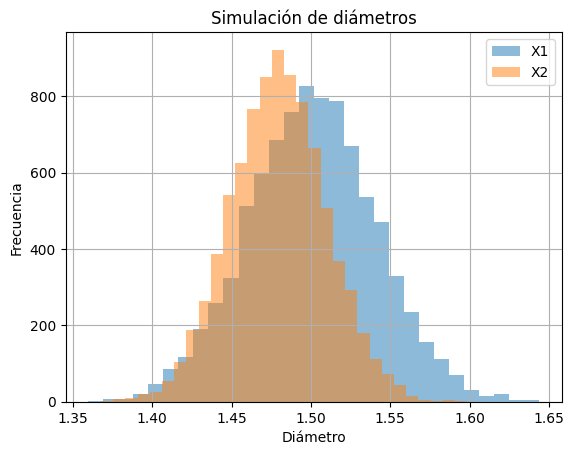

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de las distribuciones
mu1 = 1.5
var1 = 0.0016
sigma1 = np.sqrt(var1)

mu2 = 1.48
var2 = 0.0009
sigma2 = np.sqrt(var2)

# Probabilidad analítica obtenida
p = 0.3446

# Error permitido
epsilon = 0.01

# Nivel de confianza 95%
z = 1.96

# Número de simulaciones
N = int((z**2 * p * (1-p)) / (epsilon**2))

print("Número de simulaciones =", N)

# Simulación Monte Carlo
X1 = np.random.normal(mu1, sigma1, N)
X2 = np.random.normal(mu2, sigma2, N)

# Evento de interferencia
interferencia = X2 > X1

# Probabilidad estimada
p_sim = np.mean(interferencia)

print("Probabilidad analítica =", p)
print("Probabilidad simulada =", p_sim)
print("Error =", abs(p-p_sim))

# Histograma
plt.hist(X1, bins=30, alpha=0.5, label="X1")
plt.hist(X2, bins=30, alpha=0.5, label="X2")

plt.xlabel("Diámetro")
plt.ylabel("Frecuencia")
plt.title("Simulación de diámetros")

plt.grid()
plt.legend()

plt.show()

El número de simulaciones utilizado en Monte Carlo se obtuvo mediante:

$$
n=\frac{z^2p(1-p)}{\varepsilon^2}
$$

con:

$$
z=1.96
$$

$$
p=0.3446
$$

$$
\varepsilon=0.01
$$

obteniéndose:

$$
n=8674
$$

## Comparación de resultados

Resultado analítico:

$$
P(\text{interferencia})=0.3446
$$

Resultado por simulación:

$$
P_{MC}\approx 0.335984
$$

Se observa que ambos resultados son cercanos, por lo que la simulación reproduce adecuadamente el valor teórico.